# Classical Machine Learning Benchmark

This notebook evaluates classical computer vision approaches for casting product quality inspection.

The goal is to compare handcrafted image features with classical machine learning models before moving to deep learning.

### Feature representations

- Raw Pixels
- Grayscale Histogram
- Sobel
- Canny
- LBP
- HOG
- GLCM

### Classical models

- Logistic Regression
- SVM
- Random Forest

### Evaluation strategy

The original training set is split into:

- Training set: 80%
- Validation set: 20%

The test set is kept completely untouched until the final evaluation.

A fixed random seed is used to keep the split reproducible.

In [1]:
import sys
from pathlib import Path

# Add project root
sys.path.append(str(Path.cwd().parent))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
from torchvision import datasets

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from src.features.histogram import extract_histogram
from src.features.edges import extract_sobel, extract_canny
from src.features.texture import extract_lbp, extract_glcm
from src.features.hog import extract_hog

## 1. Dataset Configuration

The dataset contains two classes:

- `def_front` → Defective product
- `ok_front` → Acceptable product

The same dataset structure and split strategy as the preparation script are used here.

In [2]:
DATA_DIR = Path("../data/raw/casting_data/casting_data")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = 224
VAL_RATIO = 0.2
SEED = 42

print("Dataset:", DATA_DIR)
print("Image size:", IMG_SIZE)
print("Validation ratio:", VAL_RATIO)
print("Seed:", SEED)

Dataset: ..\data\raw\casting_data\casting_data
Image size: 224
Validation ratio: 0.2
Seed: 42


In [3]:
train_data = datasets.ImageFolder(TRAIN_DIR)
test_data = datasets.ImageFolder(TEST_DIR)

print("Classes:", train_data.classes)
print("Training images:", len(train_data))
print("Test images:", len(test_data))

Classes: ['def_front', 'ok_front']
Training images: 6633
Test images: 715


## 2. Train / Validation Split

The training images are split using the same random seed and procedure as the data preparation script.

The validation images are not used for model fitting.

The test set remains untouched.

In [4]:
generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_data),
    generator=generator
).tolist()

val_size = int(len(indices) * VAL_RATIO)

val_indices = indices[:val_size]
train_indices = indices[val_size:]

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Test images:", len(test_data))

Training images: 5307
Validation images: 1326
Test images: 715


In [5]:
all_paths = [Path(path) for path, _ in train_data.samples]
all_labels = [label for _, label in train_data.samples]

train_paths = [all_paths[i] for i in train_indices]
val_paths = [all_paths[i] for i in val_indices]

train_labels = [all_labels[i] for i in train_indices]
val_labels = [all_labels[i] for i in val_indices]

print("Train:", len(train_paths))
print("Validation:", len(val_paths))

Train: 5307
Validation: 1326


## 3. Class Distribution

The split should preserve a similar class distribution between training and validation sets.

This is only a verification step and does not modify the data.

In [6]:
def count_classes(labels):
    values, counts = np.unique(labels, return_counts=True)

    return {
        train_data.classes[int(value)]: int(count)
        for value, count in zip(values, counts)
    }


print("Training:", count_classes(train_labels))
print("Validation:", count_classes(val_labels))

Training: {'def_front': 3015, 'ok_front': 2292}
Validation: {'def_front': 743, 'ok_front': 583}


## 4. Image Loading

Images are resized to 224 × 224 to match the preparation pipeline.

No augmentation is applied during classical feature extraction.

The original image files are never modified.

In [7]:
def load_image(path):
    image = cv2.imread(str(path))

    if image is None:
        raise ValueError(f"Could not read image: {path}")

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    return image

## 5. Raw Pixel Features

The grayscale image is directly converted into a feature vector.

This provides a simple baseline for comparison with handcrafted features.

In [8]:
def extract_raw_pixels(image):
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return (
        gray.flatten()
        .astype(np.float32)
        / 255.0
    )

In [9]:
def extract_histogram_features(image):
    return extract_histogram(image)

## 6. Sobel Features

Sobel detects intensity changes in horizontal and vertical directions.

Instead of flattening the entire edge image into thousands of features, summary statistics are extracted from the gradient magnitude.

This keeps the feature vector compact.

In [10]:
def extract_sobel_features(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_32F,
        1,
        0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_32F,
        0,
        1,
        ksize=3
    )

    magnitude = cv2.magnitude(
        sobel_x,
        sobel_y
    )

    features = [
        magnitude.mean(),
        magnitude.std(),
        magnitude.min(),
        magnitude.max(),
        np.percentile(magnitude, 25),
        np.percentile(magnitude, 50),
        np.percentile(magnitude, 75),
        np.percentile(magnitude, 90),
        np.percentile(magnitude, 95),
    ]

    return np.array(
        features,
        dtype=np.float32
    )

## 7. Canny Features

Canny detects prominent edges.

Instead of storing the entire edge map, compact statistics describing the amount of detected edges are extracted.

In [11]:
def extract_canny_features(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    edges = cv2.Canny(
        gray,
        50,
        150
    )

    edge_ratio = np.mean(edges > 0)

    features = [
        edge_ratio,
        edges.mean(),
        edges.std(),
    ]

    return np.array(
        features,
        dtype=np.float32
    )

In [12]:
def extract_lbp_features(image):
    return extract_lbp(image)

In [13]:
def extract_hog_features(image):
    return extract_hog(image)

In [14]:
def extract_glcm_features(image):
    return extract_glcm(image)

## 8. Feature Representations

All feature extractors are stored in one dictionary.

This makes it easy to run the same benchmark across different feature representations.

In [15]:
FEATURE_EXTRACTORS = {
    "Raw Pixels": extract_raw_pixels,
    "Histogram": extract_histogram_features,
    "Sobel": extract_sobel_features,
    "Canny": extract_canny_features,
    "LBP": extract_lbp_features,
    "HOG": extract_hog_features,
    "GLCM": extract_glcm_features,
}

for name in FEATURE_EXTRACTORS:
    print(name)

Raw Pixels
Histogram
Sobel
Canny
LBP
HOG
GLCM


## 9. Feature Extraction

Each image is converted into a numerical feature vector.

The feature extraction process is performed separately for training and validation images.

No validation or test information is used to create training statistics.

In [16]:
def build_feature_matrix(paths, extractor):

    features = []

    for path in tqdm(paths):

        image = load_image(path)

        feature = extractor(image)

        features.append(feature)

    return np.asarray(
        features,
        dtype=np.float32
    )

## 10. Feature Extraction Check

Before processing the entire dataset, we verify the feature dimensions using one image.

In [17]:
sample_image = load_image(train_paths[0])

for name, extractor in FEATURE_EXTRACTORS.items():

    feature = extractor(sample_image)

    print(
        f"{name:15s}: {feature.shape}"
    )

Raw Pixels     : (50176,)


Histogram      : (256,)
Sobel          : (9,)
Canny          : (3,)
LBP            : (10,)
HOG            : (6084,)
GLCM           : (5,)


## 11. Classical Models

Three commonly used classical classifiers are evaluated:

- Logistic Regression
- Support Vector Machine
- Random Forest

Standardization is applied inside a pipeline for models that benefit from scaled features.

The scaler is fitted only on the training data.

In [18]:
def create_models():

    return {

        "Logistic Regression": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=SEED
                )
            )
        ]),

        "SVM": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC(
                    kernel="rbf",
                    random_state=SEED
                )
            )
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        )
    }

In [19]:
def evaluate_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val
):

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    return {
        "Accuracy": accuracy_score(
            y_val,
            predictions
        ),

        "Precision": precision_score(
            y_val,
            predictions
        ),

        "Recall": recall_score(
            y_val,
            predictions
        ),

        "F1": f1_score(
            y_val,
            predictions
        )
    }

## 12. Initial Benchmark: HOG

HOG is tested first as a sanity check before running the complete benchmark.

If this section runs successfully, the complete feature benchmark can be executed.

In [20]:
X_train_hog = build_feature_matrix(
    train_paths,
    extract_hog_features
)

X_val_hog = build_feature_matrix(
    val_paths,
    extract_hog_features
)

print("Train:", X_train_hog.shape)
print("Validation:", X_val_hog.shape)

100%|██████████| 1326/1326 [00:11<00:00, 114.37it/s]

Train: (5307, 6084)
Validation: (1326, 6084)


In [21]:
hog_results = []

models = create_models()

for model_name, model in models.items():

    print(
        f"Training {model_name}..."
    )

    metrics = evaluate_model(
        model,
        X_train_hog,
        train_labels,
        X_val_hog,
        val_labels
    )

    metrics["Feature"] = "HOG"
    metrics["Model"] = model_name

    hog_results.append(metrics)


pd.DataFrame(hog_results)

Training Logistic Regression...
Training SVM...
Training Random Forest...


,Accuracy,Precision,Recall,F1,Feature,Model
0,0.982655,0.968227,0.993139,0.980525,HOG,Logistic Regression
1,0.993213,0.989761,0.994854,0.992301,HOG,SVM
2,0.978884,0.987698,0.963979,0.975694,HOG,Random Forest


## 13. Full Classical ML Benchmark

All feature representations are now evaluated using the same classifiers.

The validation set is used only for model comparison.

The test set is not used.

In [22]:
all_results = []

feature_cache = {}

for feature_name, extractor in FEATURE_EXTRACTORS.items():

    print("\n" + "=" * 50)
    print(f"Feature: {feature_name}")
    print("=" * 50)

    # Extract training features
    X_train = build_feature_matrix(
        train_paths,
        extractor
    )

    # Extract validation features
    X_val = build_feature_matrix(
        val_paths,
        extractor
    )

    feature_cache[feature_name] = (
        X_train,
        X_val
    )

    print(
        "Train shape:",
        X_train.shape
    )

    print(
        "Validation shape:",
        X_val.shape
    )

    models = create_models()

    for model_name, model in models.items():

        print(
            f"Training: {model_name}"
        )

        metrics = evaluate_model(
            model,
            X_train,
            train_labels,
            X_val,
            val_labels
        )

        metrics["Feature"] = feature_name
        metrics["Model"] = model_name

        all_results.append(metrics)


Feature: Raw Pixels


100%|██████████| 1326/1326 [00:01<00:00, 1273.69it/s]


Train shape: (5307, 50176)
Validation shape: (1326, 50176)
Training: Logistic Regression
Training: SVM
Training: Random Forest

Feature: Histogram


100%|██████████| 1326/1326 [00:01<00:00, 856.24it/s]


Train shape: (5307, 256)
Validation shape: (1326, 256)
Training: Logistic Regression
Training: SVM
Training: Random Forest

Feature: Sobel


100%|██████████| 1326/1326 [00:05<00:00, 257.40it/s]


Train shape: (5307, 9)
Validation shape: (1326, 9)
Training: Logistic Regression
Training: SVM
Training: Random Forest

Feature: Canny


100%|██████████| 1326/1326 [00:01<00:00, 728.72it/s]


Train shape: (5307, 3)
Validation shape: (1326, 3)
Training: Logistic Regression
Training: SVM
Training: Random Forest

Feature: LBP


100%|██████████| 1326/1326 [00:10<00:00, 123.69it/s]


Train shape: (5307, 10)
Validation shape: (1326, 10)
Training: Logistic Regression
Training: SVM
Training: Random Forest

Feature: HOG


100%|██████████| 1326/1326 [00:11<00:00, 118.97it/s]


Train shape: (5307, 6084)
Validation shape: (1326, 6084)
Training: Logistic Regression
Training: SVM
Training: Random Forest

Feature: GLCM


100%|██████████| 1326/1326 [00:01<00:00, 900.19it/s]


Train shape: (5307, 5)
Validation shape: (1326, 5)
Training: Logistic Regression
Training: SVM
Training: Random Forest


## 14. Benchmark Results

Models are ranked by validation F1-score.

F1-score is used as the main comparison metric because it considers both precision and recall.

In [23]:
results_df = pd.DataFrame(
    all_results
)

results_df = results_df[
    [
        "Feature",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_df = results_df.sort_values(
    "F1",
    ascending=False
)

results_df

,Feature,Model,Accuracy,Precision,Recall,F1
4,Histogram,SVM,0.999246,0.998288,1.000000,0.999143
5,Histogram,Random Forest,0.998492,0.998285,0.998285,0.998285
8,Sobel,Random Forest,0.994721,0.991468,0.996569,0.994012
16,HOG,SVM,0.993213,0.989761,0.994854,0.992301
1,Raw Pixels,SVM,0.983409,0.973019,0.989708,0.981293
15,HOG,Logistic Regression,0.982655,0.968227,0.993139,0.980525
17,HOG,Random Forest,0.978884,0.987698,0.963979,0.975694
2,Raw Pixels,Random Forest,0.972097,0.964286,0.972556,0.968403
3,Histogram,Logistic Regression,0.964555,0.957338,0.962264,0.959795
20,GLCM,Random Forest,0.944947,0.942708,0.931389,0.937015


In [24]:
best_result = results_df.iloc[0]

print(
    "Best feature:",
    best_result["Feature"]
)

print(
    "Best model:",
    best_result["Model"]
)

print(
    "Validation F1:",
    best_result["F1"]
)

Best feature: Histogram
Best model: SVM
Validation F1: 0.9991431019708654


## 15. Feature Comparison

This visualization compares the validation F1-score of different feature representations and classifiers.

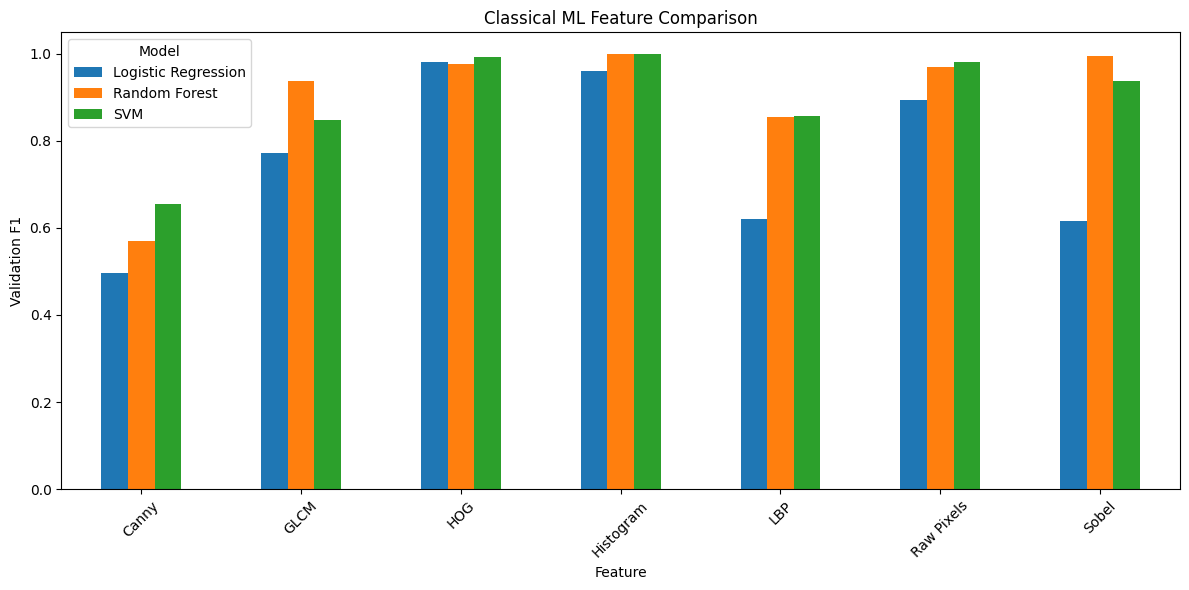

In [25]:
pivot = results_df.pivot(
    index="Feature",
    columns="Model",
    values="F1"
)

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Validation F1")
plt.xlabel("Feature")
plt.title(
    "Classical ML Feature Comparison"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. Best Model Analysis

The best configuration is evaluated in more detail using a confusion matrix and classification report.

This evaluation is still performed on the validation set.

The test set remains untouched.

In [26]:
best_feature = best_result["Feature"]
best_model_name = best_result["Model"]

X_train_best, X_val_best = feature_cache[
    best_feature
]

best_model = create_models()[
    best_model_name
]

best_model.fit(
    X_train_best,
    train_labels
)

val_predictions = best_model.predict(
    X_val_best
)

In [27]:
cm = confusion_matrix(
    val_labels,
    val_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[742   1]
 [  0 583]]


In [28]:
print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=[
            "Defective",
            "OK"
        ]
    )
)

              precision    recall  f1-score   support

   Defective       1.00      1.00      1.00       743
          OK       1.00      1.00      1.00       583

    accuracy                           1.00      1326
   macro avg       1.00      1.00      1.00      1326
weighted avg       1.00      1.00      1.00      1326



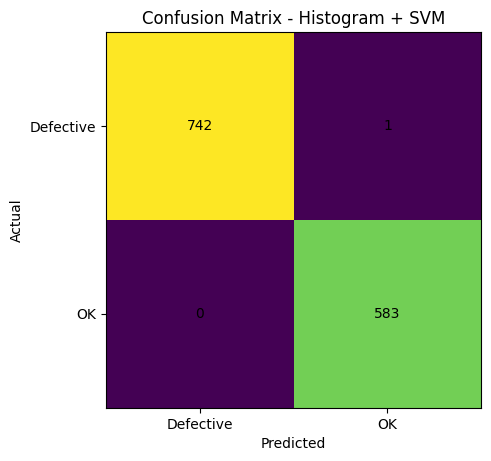

In [29]:
plt.figure(figsize=(5, 5))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix - {best_feature} + {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Defective", "OK"]
)

plt.yticks(
    [0, 1],
    ["Defective", "OK"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 17. Save Benchmark Results

The validation results are saved for later comparison with deep learning experiments.

The test set is still not used.

In [30]:
RESULTS_DIR = Path("../results/metrics")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

results_df.to_csv(
    RESULTS_DIR / "classical_ml_results.csv",
    index=False
)

print(
    "Results saved to:",
    RESULTS_DIR / "classical_ml_results.csv"
)

Results saved to: ..\results\metrics\classical_ml_results.csv


# Summary

This experiment established a classical computer vision baseline for casting product quality inspection.

Several handcrafted representations were evaluated:

- Raw Pixels
- Grayscale Histogram
- Sobel
- Canny
- LBP
- HOG
- GLCM

These representations were combined with:

- Logistic Regression
- SVM
- Random Forest

The experiments allow us to compare how different image characteristics contribute to classification performance.

The validation set was used for model and feature comparison, while the test set remained completely untouched.

The best classical configuration will be retained as a baseline for comparison with deep learning approaches.

## Next Step

The next stage is to develop deep learning baselines and transfer learning models.

The final comparison will evaluate whether learned representations from deep neural networks can outperform the handcrafted classical approaches.

## 18. Final Evaluation on Test Set

The best classical ML configuration was selected using the validation set.

The test set has not been used during feature selection or model selection.

The selected model is now evaluated once on the held-out test set to estimate its generalization performance.

In [31]:
# Get test image paths and labels
test_paths = [
    Path(path)
    for path, _ in test_data.samples
]

test_labels = [
    label
    for _, label in test_data.samples
]

print("Test images:", len(test_paths))
print("Classes:", test_data.classes)

Test images: 715
Classes: ['def_front', 'ok_front']


In [32]:
X_test = build_feature_matrix(
    test_paths,
    extract_histogram_features
)

print("Test feature shape:", X_test.shape)

100%|██████████| 715/715 [00:15<00:00, 45.31it/s]

Test feature shape: (715, 256)


In [33]:
# Combine train and validation data
X_train_final = np.concatenate(
    [X_train_best, X_val_best],
    axis=0
)

y_train_final = np.concatenate(
    [train_labels, val_labels],
    axis=0
)

print("Final training data:", X_train_final.shape)

Final training data: (6633, 256)


In [34]:
final_model = create_models()["SVM"]

final_model.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [35]:
test_predictions = final_model.predict(
    X_test
)

In [36]:
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions
)

test_recall = recall_score(
    test_labels,
    test_predictions
)

test_f1 = f1_score(
    test_labels,
    test_predictions
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1       : {test_f1:.4f}")

Test Accuracy : 0.9986
Test Precision: 1.0000
Test Recall   : 0.9962
Test F1       : 0.9981


In [40]:
cm_test = confusion_matrix(
    test_labels,
    test_predictions
)

print(cm_test)

[[453   0]
 [  1 261]]


In [42]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=test_data.classes
    )
)

              precision    recall  f1-score   support

   def_front       1.00      1.00      1.00       453
    ok_front       1.00      1.00      1.00       262

    accuracy                           1.00       715
   macro avg       1.00      1.00      1.00       715
weighted avg       1.00      1.00      1.00       715



In [43]:
wrong_indices = np.where(
    np.array(test_predictions) != np.array(test_labels)
)[0]

print("Wrong images:", len(wrong_indices))

for i in wrong_indices:
    print("Image:", test_paths[i])
    print("Actual:", test_data.classes[test_labels[i]])
    print("Predicted:", test_data.classes[test_predictions[i]])

Wrong images: 1
Image: ..\data\raw\casting_data\casting_data\test\ok_front\cast_ok_0_9925.jpeg
Actual: ok_front
Predicted: def_front


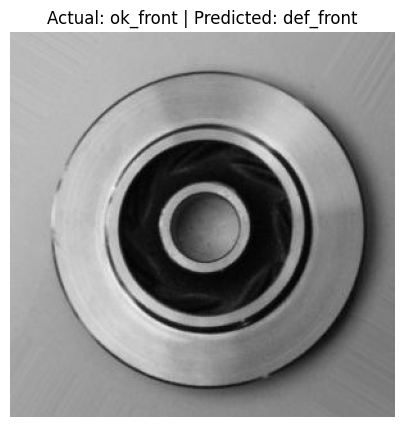

In [44]:
i = wrong_indices[0]

image = cv2.imread(str(test_paths[i]))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Actual: {test_data.classes[test_labels[i]]} | "
    f"Predicted: {test_data.classes[test_predictions[i]]}"
)
plt.axis("off")
plt.show()